# CDFNet processing example

Isca data output processing example

In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def fix(ds):
    for v in ds.variables:
        if 'units' in ds[v].attrs and '0000-00-00' in ds[v].attrs['units']:
            ds[v].attrs['units'] = ds[v].attrs['units'].replace('0000-00-00', '0001-01-01')
        if ds[v].attrs.get('calendar') == 'NO_CALENDAR':
            ds[v].attrs['calendar'] = '360_day'
    return ds

ds_raw = xr.open_mfdataset(
    '../.isca_data/barotropic_stirring/run*/atmos_daily.nc',
    combine='by_coords',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    decode_times=False,
    preprocess=fix
)

ds = xr.decode_cf(ds_raw, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True), decode_timedelta=True)
print("Loaded")

Loaded


In [25]:
coord_desc = {
    "lon": "Longitude of the grid cell centers",
    "lonb": "Longitude of the grid cell boundaries (edges)",
    "lat": "Latitude of the grid cell centers",
    "latb": "Latitude of the grid cell boundaries (edges)",
    "time": "Time axis (centered on the averaging period)",
    "nv": "Number of vertices (used for boundary dimensions)"
}

print("Coordinates:")
for coord in ds.coords:
    desc = coord_desc.get(coord, "No description :(")
    print(f" - {coord:10}: {desc}")

Coordinates:
 - lon       : Longitude of the grid cell centers
 - lonb      : Longitude of the grid cell boundaries (edges)
 - lat       : Latitude of the grid cell centers
 - latb      : Latitude of the grid cell boundaries (edges)
 - time      : Time axis (centered on the averaging period)
 - nv        : Number of vertices (used for boundary dimensions)


In [26]:
var_desc = {
    "ucomp": "Zonal (East-West) wind component",
    "vcomp": "Meridional (North-South) wind component",
    "vor": "Relative vorticity",
    "pv": "Potential vorticity",
    "stream": "Streamfunction (isolines of flow)",
    "trs": "Tracer source term",
    "tr": "Passive tracer concentration",
    "eddy_vor": "Vorticity of the transient eddies",
    "delta_u": "Change in zonal wind",
    "stirring": "Stirring forcing term",
    "stirring_amp": "Amplitude of the stirring forcing",
    "stirring_sqr": "Square of the stirring forcing",
    "average_T1": "Start time of averaging window",
    "average_T2": "End time of averaging window",
    "average_DT": "Length of averaging window",
    "time_bounds": "Time boundaries for each data point"
}

print("Variables:")
for var in ds.data_vars:
    desc = var_desc.get(var, "No description :(")
    print(f" - {var:15}: {desc}")

Variables:
 - ucomp          : Zonal (East-West) wind component
 - vcomp          : Meridional (North-South) wind component
 - vor            : Relative vorticity
 - pv             : Potential vorticity
 - stream         : Streamfunction (isolines of flow)
 - trs            : Tracer source term
 - tr             : Passive tracer concentration
 - eddy_vor       : Vorticity of the transient eddies
 - delta_u        : Change in zonal wind
 - stirring       : Stirring forcing term
 - stirring_amp   : Amplitude of the stirring forcing
 - stirring_sqr   : Square of the stirring forcing
 - average_T1     : Start time of averaging window
 - average_T2     : End time of averaging window
 - average_DT     : Length of averaging window
 - time_bounds    : Time boundaries for each data point


In [27]:
def plot_variable_evolution(data_array, slices, units="", title="", description="", 
                            cmap="seismic", robust_scaling=True):
    """
    Plots the temporal evolution of a 2D scalar field with high-contrast color handling.
    
    Args:
        data_array: xarray.DataArray (time, lat, lon)
        slices: List of time indices to plot
        units: String for the colorbar label (e.g., "[$s^{-1}$]")
        title: Main figure title
        description: Text to display below the figure
        cmap: Matplotlib colormap string. 
            Recommended for Diverging (Vorticity/Wind): 
                'seismic' (High contrast), 'RdBu_r' (Standard), 'bwr' (Blue-White-Red), 
                'PuOr' (Purple-Orange), 'coolwarm' (Smooth transition).
            Recommended for Sequential (Tracers/Speed): 
                'viridis', 'magma', 'inferno', 'YlGnBu'.
        robust_scaling: If True, uses 95th percentile of all data for a shared scale.
                        If False, scales each frame to its own local max.
    """
    num_plots = len(slices)
    cols = 5
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), 
                             sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # Calculation for Global robust scaling
    global_vmax = np.percentile(np.abs(data_array.values), 95)

    for i, idx in enumerate(slices):
        step_data = data_array.isel(time=idx)
        
        # Determine limits
        v_lim = global_vmax if robust_scaling else abs(step_data).max().values

        im = step_data.plot(ax=axes[i], cmap=cmap, vmin=-v_lim, vmax=v_lim, 
                            add_colorbar=False, add_labels=False)
        
        local_max = step_data.max().values
        axes[i].set_title(f"Day {step_data.time.values}\nMax: {local_max:.2e}")

    # Colorbar and Meta-info
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8)
    cbar.set_label(f"{units}", fontsize=12)
    
    cmap_meta = (
        f"Colormap: '{cmap}' | Scale Limit: ±{global_vmax:.2e}" 
        if robust_scaling else f"Colormap: '{cmap}' | Local Scaling"
    )
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    full_footer = f"{description}\n{cmap_meta}"
    fig.text(0.5, -0.05, full_footer, ha='center', fontsize=11, style='italic', wrap=True)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.show()

# --- Invoke on Vorticity ---

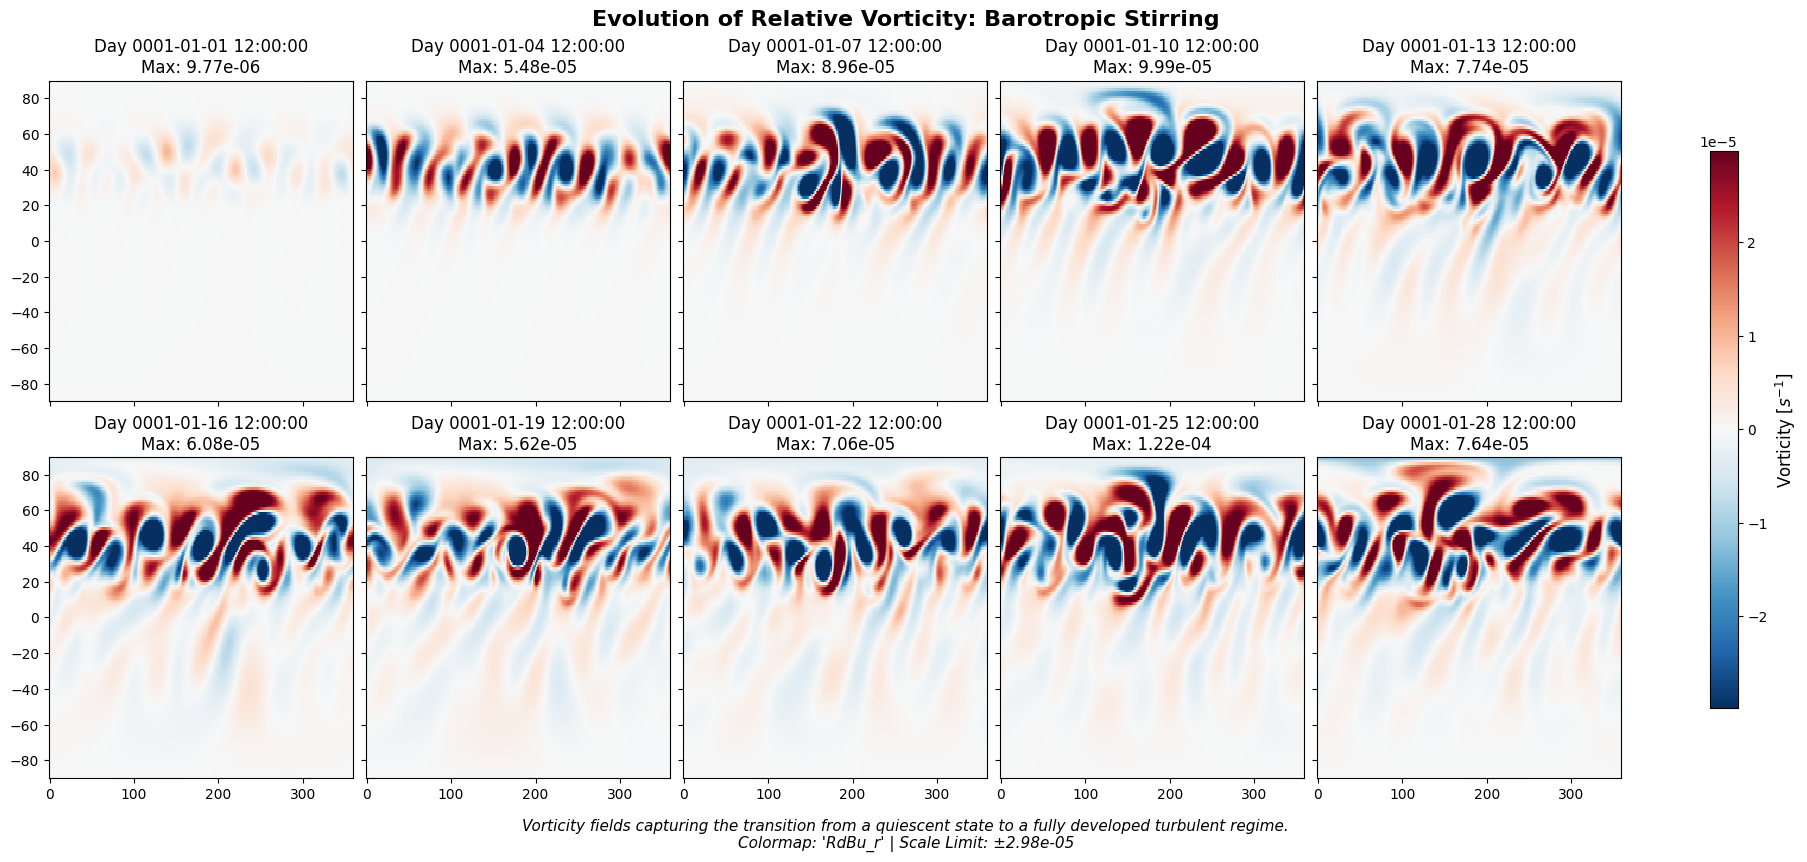

In [28]:
selected_indices = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27]

plot_variable_evolution(
    data_array=ds.vor, 
    slices=selected_indices,
    units="Vorticity [$s^{-1}$]",
    title="Evolution of Relative Vorticity: Barotropic Stirring",
    description="Vorticity fields capturing the transition from a quiescent state to a fully developed turbulent regime.",
    cmap="RdBu_r",
    robust_scaling=True
)